In [5]:
import torch
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Render matplotlib plots inline
%matplotlib inline

# Robust path resolution assuming notebook is in the scripts/ directory
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [6]:
def compute_sliced_wasserstein_distance(X: torch.Tensor, Y: torch.Tensor, num_projections: int = 1000) -> float:
    """
    Computes the 2-Sliced-Wasserstein Distance (SWD) between two empirical distributions.
    This serves as a tractable proxy for the continuous Wasserstein-2 distance required 
    by the theoretical Minimax bounds.
    """
    p = X.size(1)
    device = X.device
    
    # 1. Sample uniformly from the unit hypersphere in R^p
    projections = torch.randn(p, num_projections, device=device)
    projections = projections / torch.norm(projections, dim=0, keepdim=True)
    
    # 2. Project both distributions onto the random directions
    X_proj = torch.matmul(X, projections)
    Y_proj = torch.matmul(Y, projections)
    
    # 3. Sort the projections to compute the 1D Wasserstein distances
    X_proj_sorted, _ = torch.sort(X_proj, dim=0)
    Y_proj_sorted, _ = torch.sort(Y_proj, dim=0)
    
    # Enforce symmetric comparison through downsampling if sizes differ
    if X.size(0) != Y.size(0):
        min_size = min(X.size(0), Y.size(0))
        X_proj_sorted = X_proj_sorted[torch.randperm(X.size(0))[:min_size].sort()[0]]
        Y_proj_sorted = Y_proj_sorted[torch.randperm(Y.size(0))[:min_size].sort()[0]]

    # 4. Compute the expected L2 distance across all projections
    wasserstein_distance = torch.mean((X_proj_sorted - Y_proj_sorted) ** 2)
    
    return torch.sqrt(wasserstein_distance).item()

In [7]:
def plot_pca_comparison(target_data: np.ndarray, generated_data: np.ndarray, output_path: str = None):
    """
    Executes PCA to project the p-dimensional ambient space down to 3 dimensions
    for direct visual topological comparison. Renders the plot inline.
    """
    # Fit PCA strictly on the target manifold to establish principal geometric axes
    pca = PCA(n_components=3)
    target_pca = pca.fit_transform(target_data)
    
    # Project the generated data using the exact same basis
    generated_pca = pca.transform(generated_data)
    
    # Construct a 3D dual-plot
    fig = plt.figure(figsize=(16, 8))
    
    # Subplot 1: Target Manifold
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(target_pca[:, 0], target_pca[:, 1], target_pca[:, 2], 
                c='blue', alpha=0.3, s=10, label='True Target Manifold')
    ax1.set_title(f"Target Distribution (PCA)\nExplained Variance: {sum(pca.explained_variance_ratio_):.2f}")
    ax1.legend()
    
    # Subplot 2: Generated Manifold
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(generated_pca[:, 0], generated_pca[:, 1], generated_pca[:, 2], 
                c='red', alpha=0.3, s=10, label='Generated SDE Manifold')
    ax2.set_title("Generated Distribution (PCA)")
    ax2.legend()
    
    # Synchronize camera angles
    ax1.view_init(elev=20., azim=45)
    ax2.view_init(elev=20., azim=45)
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300)
        print(f"Visualization saved successfully to: {output_path}")
        
    # Render inline in the notebook
    plt.show()

Loading empirical tensors...
Computing Sliced-Wasserstein Distance (SWD)...


/tmp/ipykernel_57860/2438428937.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  target_data = torch.load(target_path, map_location='cpu')
/tmp/ipykernel_57860/243842893


[METRIC] Sliced-Wasserstein Distance: 19.220572

Executing Principal Component Analysis for 3D visualization...
Visualization saved successfully to: /home/arthur/Desktop/ManifoldReconstruction/generative_model_arch/data/analysis/manifold_comparison_pca.png


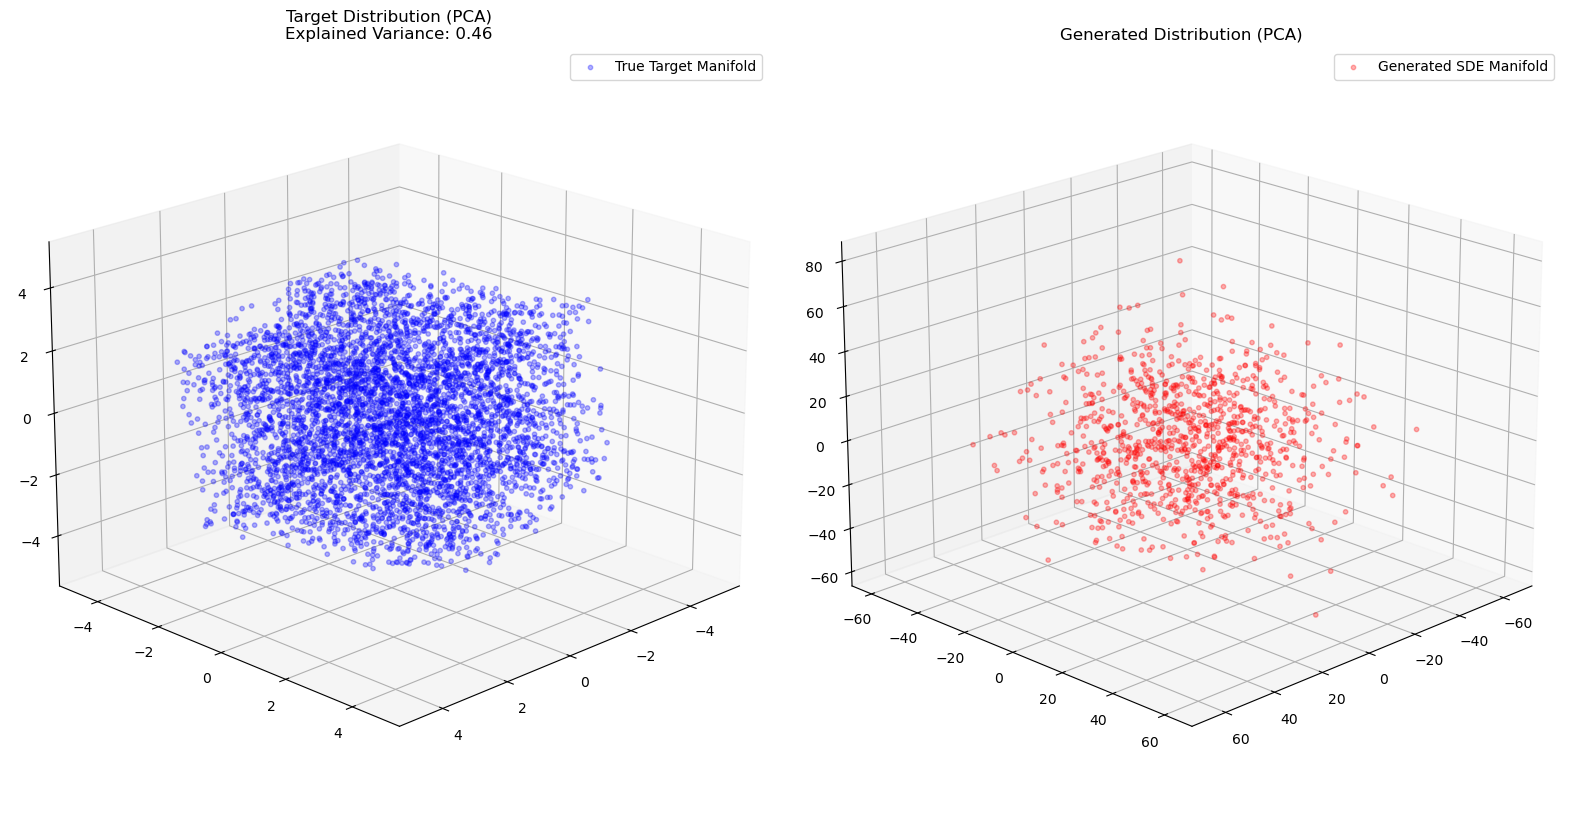

In [8]:
# Configuration Variables
target_path = os.path.join(project_root, "data", "raw", "dataset.pt")
generated_path = os.path.join(project_root, "data", "processed", "generated_samples.pt")
output_dir = os.path.join(project_root, "data", "analysis")

os.makedirs(output_dir, exist_ok=True)

if not os.path.exists(target_path) or not os.path.exists(generated_path):
    raise FileNotFoundError("Missing target or generated data tensors. Ensure Phase 0 through Phase 3 have been completed.")

# 1. Load Data
print("Loading empirical tensors...")
target_data = torch.load(target_path, map_location='cpu')
generated_data = torch.load(generated_path, map_location='cpu')

# 2. Metric Evaluation: Sliced-Wasserstein Distance
print("Computing Sliced-Wasserstein Distance (SWD)...")
swd_score = compute_sliced_wasserstein_distance(target_data, generated_data)
print(f"\n[METRIC] Sliced-Wasserstein Distance: {swd_score:.6f}")

# 3. Topological Visualization
print("\nExecuting Principal Component Analysis for 3D visualization...")
plot_path = os.path.join(output_dir, "manifold_comparison_pca.png")
plot_pca_comparison(target_data.numpy(), generated_data.numpy(), output_path=plot_path)